In [1]:
from pyteomics import fasta
from collections import namedtuple
from collections import defaultdict

In [6]:
Protein = namedtuple('Protein', ['id','description','sequence'])
FastaDatabase = namedtuple('FastaDatabase', ['file_path', 'proteins'])

def create_fasta_database(database_file_path):
    fasta_database = FastaDatabase(database_file_path,{})
    prots = []
    for entry in fasta.read(database_file_path):
        prots.append(entry)
    fasta_database = fasta_database._replace(proteins=prots)
    return fasta_database  

In [3]:
# Define amino acid molecular weights (in Daltons)
amino_acid_weights = {
    'A': 71.08,  # Alanine
    'R': 156.19, # Arginine
    'N': 114.11, # Asparagine
    'D': 115.09, # Aspartic Acid
    'C': 103.15, # Cysteine
    'E': 129.12, # Glutamic Acid
    'Q': 128.13, # Glutamine
    'G': 57.05,  # Glycine
    'H': 137.14, # Histidine
    'I': 113.16, # Isoleucine
    'L': 113.16, # Leucine
    'K': 128.17, # Lysine
    'M': 131.19, # Methionine
    'F': 147.18, # Phenylalanine
    'P': 97.12,  # Proline
    'S': 87.08,  # Serine
    'T': 101.11, # Threonine
    'W': 186.21, # Tryptophan
    'Y': 163.18, # Tyrosine
    'V': 99.13   # Valine
}

def calculate_protein_weight(sequence):
    total_weight = 0.0
    for amino_acid in sequence:
        total_weight += amino_acid_weights.get(amino_acid, 0.0)
    return total_weight


In [7]:
database_file_path = '/Users/jamesdixon/Documents/hypedsearch/data/database/sample_database.fasta'
fasta_database = create_fasta_database(database_file_path)

for protein in fasta_database.proteins:
    sequence = protein.sequence
    sequence_weight = calculate_protein_weight(sequence)
    print(f"Sequence: {sequence}, Weight: {sequence_weight}")


Sequence: MSSPPEGKLETKAGHPPAVKAGGMRIVQKHPHTGDGKEERDKDDQEWESTSPPKPTVFISGVIARGDKDFPPAAAQVAHQKPHASMDKHVSPRTQHIQQPRK, Weight: 11136.569999999998
Sequence: MGDREQLLQRARLAEQAERYDDMASAMKAVTELNEPLSNEDRNLLSVAYKNVVGARRSSWRVISSIEQKTMADGNEKKLEKVKAYREKIEKELETVCNDVLALLDKFLIKNCNDFQYESKVFYLKMKGDYYRYLAEVASGEKKNSVVEASEAAYKEAFEISKEHMQPTHPIRLGLALNFSVFYYEIQNAPEQACLLAKQAFDDAIAELDTLNEDSYKDSTLIMQLLRDNLTLWTSDQQDEEAGEGN, Weight: 28194.06000000002
Sequence: MADPRVRQIKIKTGVVRRLVKERVMYEKEAKQQEEKIEKMKAEDGENYAIKKQAEILQESRMMIPDCQRRLEAAYTDLQQILESEKDLEEAEEYKEARVVLDSVKLEA, Weight: 12739.750000000002
Sequence: MSLRFGATCLLSFSFLLLITSSDGRTGLGKGFGDHIHWRTLEDGKKEAAASGLPLMVIIHKSWCGACKALKPKFAESTEISELSHNFVMVNLEDEEEPRDEDFSPDGGYIPRILFLDPSGKVRPEIINESGNPSYKYFYVSAEQVVQGMKEAQERLTGDAFREKHFQDEL, Weight: 19030.760000000002
Sequence: MAASRALSLTAEAVRAVIPRRSGRLLAVFPRLLTRWETTSSIPEAGEGQIRLTDSCVQRLLEITEGSEFLRLQVEGGGCSGFQYKFSLDTVINPDDRVFEQGGARVVVDSDSLAFVKGAQVDFSQELIRSSFQVLNNPQAQQGCSCGSSFSVKV, Weight: 16700.099999999984
Sequence: MVQAWYMDESTADPRK

In [8]:
database_file_path = '/Users/jamesdixon/Documents/hypedsearch/data/database/sample_database.fasta'
fasta_database = create_fasta_database(database_file_path)

for protein in fasta_database.proteins:
    sequence = protein.sequence
    sequence_weight = round(calculate_protein_weight(sequence))

In [11]:
database_file_path = '/Users/jamesdixon/Documents/hypedsearch/data/database/sample_database.fasta'
fasta_database = create_fasta_database(database_file_path)

kmer_weights = defaultdict(list)

for protein in fasta_database.proteins:
    sequence = protein.sequence
    for kmer_length in range(2, 21):
        for i in range(len(sequence) - kmer_length + 1):
            kmer = sequence[i:i + kmer_length]
            kmer_weight = round(calculate_protein_weight(kmer))
            kmer_weights[kmer].append(kmer_weight)

first_kmer, first_weights = next(iter(kmer_weights.items()))
print(f"K-mer: {first_kmer}, Weights: {first_weights}")
print(f"Number of k-mers: {len(kmer_weights)}")


K-mer: MS, Weights: [218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218]
Number of k-mers: 1640772


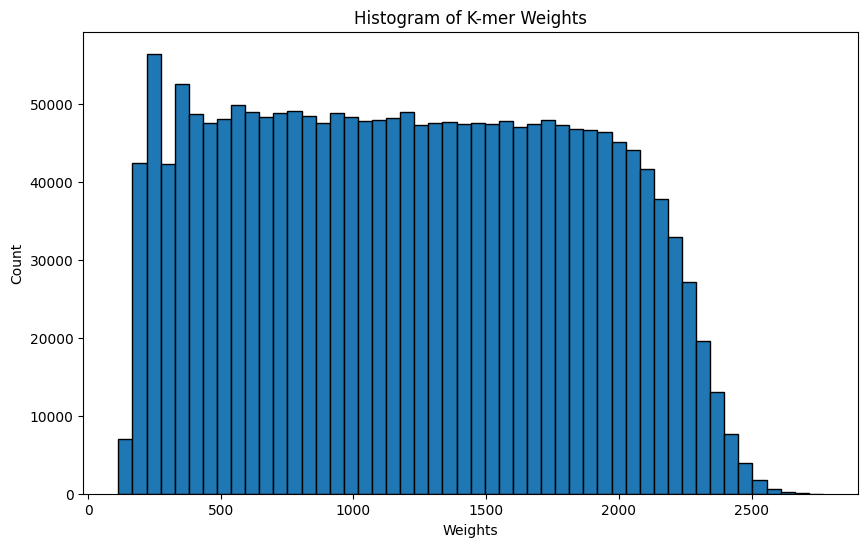

In [12]:
import matplotlib.pyplot as plt

all_weights = [weight for weights in kmer_weights.values() for weight in weights]

plt.figure(figsize=(10, 6))
plt.hist(all_weights, bins=50, edgecolor='black')

plt.xlabel('Weights')
plt.ylabel('Count')
plt.title('Histogram of K-mer Weights')

plt.show()

In [15]:
import matplotlib.pyplot as plt

all_weights = [weight for weights in kmer_weights.values() for weight in weights]

possible_weights = set(range(0, 2501))
actual_weights = set(all_weights)
missing_weights = possible_weights - actual_weights

# Print missing weights
print("Weights not recorded in the data:")
print(sorted(missing_weights))

Weights not recorded in the data:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 143, 145, 146, 147, 148, 149, 150, 151, 152, 153, 155, 157, 159, 161, 162, 163, 164, 165, 166, 167, 169, 173, 175, 176, 177, 178, 179, 180, 181, 182, 183, 187, 189, 191, 192, 193, 195, 197, 203, 205, 207, 209, 219, 221, 222, 223, 233, 235, 237, 249, 254, 280, 290, 306]
